# Random Forest y comparación con modelos anteriores

## Objetivos 

En esta sesión se busca:

1. Introducir el modelo de **Random Forest**.
2. Compararlo con la **regresión logística** y el **árbol de decisión**.
3. Evaluar los tres modelos con métricas comparables.
4. Analizar si un ensamble de árboles mejora el desempeño de un árbol individual.
5. Identificar las variables más importantes según Random Forest.

## Contexto

En la sesión anterior se observó que el árbol de decisión logró detectar más incumplimientos que la regresión logística, pero con una pérdida importante en precisión y desempeño global.

Random Forest busca corregir parte de esa inestabilidad combinando múltiples árboles de decisión entrenados sobre distintas muestras y subconjuntos de variables. En esta sesión se evaluará si esta estrategia produce un modelo más robusto y con mejor capacidad predictiva.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [4]:
df = pd.read_csv("default_credit_clean.csv")

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()

Dimensiones del dataset: (30000, 29)

Primeras columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


## Separación de predictores y variable objetivo

En esta sección se define:

- `X`: conjunto de variables predictoras,
- `y`: variable objetivo `default_next_month`.

También se eliminan columnas que no deben entrar directamente en el modelado, como el identificador `ID` y las etiquetas auxiliares de texto.

In [5]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']


## División en entrenamiento y prueba

Para comparar de forma justa los tres modelos, se utilizará la misma partición en entrenamiento y prueba.

La partición será:

- **80%** para entrenamiento,
- **20%** para prueba,

y además será **estratificada**, para conservar aproximadamente la misma proporción de incumplimiento en ambos subconjuntos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción de incumplimiento en y_train:", y_train.mean())
print("Proporción de incumplimiento en y_test :", y_test.mean())

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)

Proporción de incumplimiento en y_train: 0.22120833333333334
Proporción de incumplimiento en y_test : 0.22116666666666668


## Identificación de variables numéricas y categóricas

Antes de entrenar los modelos, se distinguen las variables que serán tratadas como:

- **categóricas**, usando codificación `one-hot`,
- **numéricas**, usando imputación y, en el caso de la regresión logística, escalamiento.

Las variables categóricas consideradas serán:

- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

El resto se tratará como variables numéricas.

In [7]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nNúmero de variables categóricas:", len(categorical_features))

print("\nVariables numéricas:")
print(numeric_features)

print("\nNúmero de variables numéricas:", len(numeric_features))

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

Número de variables categóricas: 4

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Número de variables numéricas: 20




Las variables predictoras se dividieron en dos grupos:

### Variables categóricas
- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

Estas variables serán codificadas mediante **one-hot encoding**, ya que representan categorías y no deben tratarse como magnitudes continuas.

### Variables numéricas
Las otras **20 variables** se considerarán numéricas, incluyendo:

- `LIMIT_BAL` y `AGE`,
- el historial de pagos (`PAY_0`, `PAY_2`, ..., `PAY_6`),
- los montos facturados (`BILL_AMT1` a `BILL_AMT6`),
- y los montos pagados (`PAY_AMT1` a `PAY_AMT6`).

Esta separación permitirá construir pipelines apropiados para cada tipo de modelo. En particular:

- la **regresión logística** requiere escalamiento en las variables numéricas,
- mientras que el **árbol de decisión** y **Random Forest** no lo necesitan estrictamente.

## Preprocesamiento para la regresión logística

La regresión logística requiere que las variables numéricas estén en escalas comparables. Por ello, se definirá un pipeline con:

- **variables numéricas**:
  - imputación por mediana,
  - escalamiento estandarizado;

- **variables categóricas**:
  - imputación por la categoría más frecuente,
  - codificación `one-hot`.

Este preprocesamiento será usado únicamente para la regresión logística.

In [8]:
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer_lr, categorical_features)
    ]
)

print(preprocessor_lr)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  



El `ColumnTransformer` para la regresión logística se definió correctamente y presenta dos rutas de transformación diferenciadas:

### Variables numéricas
Se aplicará un pipeline con:

1. **Imputación por mediana**, para manejar posibles valores faltantes.
2. **Escalamiento estandarizado**, para que las variables queden en escalas comparables.

Esto es importante porque la regresión logística puede verse afectada por diferencias grandes de magnitud entre variables como `LIMIT_BAL`, `BILL_AMT*` y `PAY_AMT*`.

### Variables categóricas
Se aplicará un segundo pipeline con:

1. **Imputación por la categoría más frecuente**,
2. **Codificación one-hot**, eliminando la primera categoría para evitar redundancia.

Con esto, la regresión logística recibirá una representación adecuada de las variables numéricas y categóricas.

## Preprocesamiento para el árbol de decisión y Random Forest

Tanto el árbol de decisión como Random Forest no requieren escalamiento de las variables numéricas. Sin embargo, sí conviene:

- imputar valores faltantes,
- y codificar las variables categóricas.

Por ello, se construirá un pipeline común para ambos modelos, sin incluir `StandardScaler`.

In [9]:
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

print(preprocessor_tree)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                   



El `ColumnTransformer` para el árbol de decisión y Random Forest se definió correctamente. Su estructura distingue dos rutas:

### Variables numéricas
Se aplicará únicamente:

- **imputación por mediana**.

No se incluye escalamiento porque estos modelos basados en árboles toman decisiones mediante particiones y umbrales, por lo que no dependen de la escala de las variables de la misma manera que la regresión logística.

### Variables categóricas
Se aplicará:

- **imputación por la categoría más frecuente**,
- y **codificación one-hot**.

Con este pipeline, tanto el árbol de decisión como Random Forest recibirán datos limpios y bien codificados, sin imponer transformaciones innecesarias.

## Entrenamiento de los tres modelos

En esta sección se entrenarán los tres modelos que se desean comparar:

- **Regresión logística**,
- **Árbol de decisión**,
- **Random Forest**.

Cada modelo utilizará su pipeline de preprocesamiento correspondiente.

In [11]:
# Regresión logística
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

# Árbol de decisión
tree_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE',
                                                   'AGE_GROUP'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])



Los tres modelos se entrenaron correctamente sobre el conjunto de entrenamiento:

- **Regresión logística**,
- **Árbol de decisión**,
- **Random Forest**.

Esto significa que ya se cuenta con tres enfoques distintos para el mismo problema:

1. **Regresión logística**  
   Modelo lineal e interpretable, útil como baseline.

2. **Árbol de decisión**  
   Modelo no lineal que aprende reglas de decisión a partir de particiones sucesivas.

3. **Random Forest**  
   Modelo de ensamble que combina muchos árboles y busca reducir la inestabilidad de un árbol individual.

A partir de aquí, el siguiente paso será comparar sus predicciones y evaluar cuál ofrece mejor equilibrio entre desempeño global y detección de incumplimientos.

## Predicciones y probabilidades de los tres modelos

Para comparar adecuadamente los tres enfoques, se obtendrán:

- predicciones de clase,
- y probabilidades estimadas de incumplimiento,

en el conjunto de prueba.

In [12]:
# Regresión logística
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Árbol de decisión
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades de regresión logística:")
print(y_proba_lr[:10])

print("\nPrimeras 10 probabilidades del árbol de decisión:")
print(y_proba_tree[:10])

print("\nPrimeras 10 probabilidades de Random Forest:")
print(y_proba_rf[:10])

Primeras 10 probabilidades de regresión logística:
[0.10806998 0.11724991 0.2223453  0.09658985 0.02977732 0.21014218
 0.13061203 0.15772985 0.0784884  0.19577078]

Primeras 10 probabilidades del árbol de decisión:
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]

Primeras 10 probabilidades de Random Forest:
[0.155 0.215 0.21  0.18  0.015 0.415 0.09  0.    0.09  0.04 ]



Las primeras probabilidades estimadas muestran diferencias claras entre los tres modelos:

### Regresión logística
La regresión logística produce **probabilidades continuas y graduales**, con valores relativamente bajos en estos primeros casos. Esto es consistente con su naturaleza probabilística y con el hecho de que genera una estimación suave del riesgo.

### Árbol de decisión
El árbol de decisión produce aquí probabilidades **extremas**, en este ejemplo `0` o `1`. Esto refleja un comportamiento típico de los árboles individuales: la probabilidad depende de la composición de las hojas terminales y puede resultar muy brusca o poco refinada.

### Random Forest
Random Forest también produce probabilidades continuas, pero se observa que son más **intermedias y estables** que las del árbol individual. Esto ocurre porque el modelo combina la salida de muchos árboles, lo que suaviza las probabilidades finales.

En conjunto, estas primeras observaciones sugieren que:

- la **regresión logística** da probabilidades continuas y conservadoras,
- el **árbol de decisión** tiende a respuestas más extremas,
- y **Random Forest** ofrece una salida intermedia, combinando flexibilidad no lineal con mayor estabilidad.

Esta diferencia será importante al comparar el desempeño global de los tres modelos.

## Función auxiliar para evaluar modelos

Para comparar los tres modelos con el mismo criterio, se define una función que calcule las métricas principales de clasificación:

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- `ROC-AUC`

Estas métricas se calcularán sobre el conjunto de prueba.

In [13]:
def evaluar_modelo(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

resultados_modelos = pd.DataFrame({
    "Logistic Regression": evaluar_modelo(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree": evaluar_modelo(y_test, y_pred_tree, y_proba_tree),
    "Random Forest": evaluar_modelo(y_test, y_pred_rf, y_proba_rf)
})

resultados_modelos

,Logistic Regression,Decision Tree,Random Forest
accuracy,0.8085,0.7162,0.8127
precision,0.6894,0.3672,0.6327
recall,0.2442,0.3919,0.3647
f1,0.3606,0.3791,0.4627
roc_auc,0.7102,0.6005,0.7575




La tabla comparativa muestra diferencias importantes entre los tres enfoques.

### Regresión logística
- **Accuracy = 0.8085**
- **Precision = 0.6894**
- **Recall = 0.2442**
- **F1 = 0.3606**
- **ROC-AUC = 0.7102**

La regresión logística mantiene un comportamiento conservador: logra una precisión alta, pero detecta sólo una fracción reducida de los incumplimientos reales.

### Árbol de decisión
- **Accuracy = 0.7162**
- **Precision = 0.3672**
- **Recall = 0.3919**
- **F1 = 0.3791**
- **ROC-AUC = 0.6005**

El árbol de decisión detecta más incumplimientos que la regresión logística, pero lo hace con menor precisión y menor capacidad discriminante global. En esta versión, su desempeño general es el más débil de los tres.

### Random Forest
- **Accuracy = 0.8127**
- **Precision = 0.6327**
- **Recall = 0.3647**
- **F1 = 0.4627**
- **ROC-AUC = 0.7575**

Random Forest logra el mejor equilibrio global entre los tres modelos:

- obtiene el **mayor accuracy**,
- el **mayor F1-score**,
- y el **mayor ROC-AUC**.

Además, su `recall` es claramente superior al de la regresión logística, aunque algo menor que el del árbol de decisión. Su `precision` también es bastante mejor que la del árbol individual.

### Interpretación general
En conjunto, los resultados sugieren que:

- la **regresión logística** sigue siendo un baseline sólido y preciso, pero demasiado conservador;
- el **árbol de decisión** gana en detección de incumplimientos, pero con bajo control de errores;
- **Random Forest** parece combinar mejor ambas virtudes: conserva la flexibilidad de los árboles, pero con mayor estabilidad y mejor desempeño global.

En esta comparación, **Random Forest** aparece como el modelo más prometedor hasta el momento.

## Matrices de confusión de los tres modelos

Para profundizar en la comparación, se construirán las matrices de confusión de:

- la regresión logística,
- el árbol de decisión,
- y Random Forest.

Esto permitirá observar con más detalle cómo se distribuyen los aciertos y errores de cada modelo.

In [17]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_lr_df = pd.DataFrame(
    cm_lr,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

cm_tree_df = pd.DataFrame(
    cm_tree,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

print("Matriz de confusión - Regresión logística")
display(cm_lr_df)

print("Matriz de confusión - Árbol de decisión")
display(cm_tree_df)

print("Matriz de confusión - Random Forest")
display(cm_rf_df)

Matriz de confusión - Regresión logística


,Pred: No default,Pred: Default
Real: No default,4527,146
Real: Default,1003,324


Matriz de confusión - Árbol de decisión


,Pred: No default,Pred: Default
Real: No default,3777,896
Real: Default,807,520


Matriz de confusión - Random Forest


,Pred: No default,Pred: Default
Real: No default,4392,281
Real: Default,843,484




Las matrices de confusión permiten comparar con más detalle cómo se comporta cada modelo en el conjunto de prueba.

### Regresión logística
- **Verdaderos negativos:** 4527
- **Falsos positivos:** 146
- **Falsos negativos:** 1003
- **Verdaderos positivos:** 324

La regresión logística clasifica muy bien a la clase mayoritaria (`No default`) y comete pocos falsos positivos. Sin embargo, deja escapar muchos incumplimientos reales.

### Árbol de decisión
- **Verdaderos negativos:** 3777
- **Falsos positivos:** 896
- **Falsos negativos:** 807
- **Verdaderos positivos:** 520

El árbol de decisión detecta más incumplimientos que la regresión logística, pero lo hace con un costo muy alto en falsos positivos. Es el modelo más agresivo al señalar clientes como riesgosos.

### Random Forest
- **Verdaderos negativos:** 4392
- **Falsos positivos:** 281
- **Falsos negativos:** 843
- **Verdaderos positivos:** 484

Random Forest logra un punto intermedio muy interesante:

- detecta más incumplimientos que la regresión logística,
- pero con muchos menos falsos positivos que el árbol de decisión.

### Comparación general
En términos prácticos:

- la **regresión logística** es el modelo más conservador,
- el **árbol de decisión** es el más agresivo,
- y **Random Forest** logra un equilibrio más razonable entre detectar incumplimientos y evitar falsas alarmas.

Esto ayuda a explicar por qué Random Forest obtuvo el mejor `F1-score` y el mejor `ROC-AUC` en la comparación anterior.

## Visualización de las matrices de confusión

Para complementar la comparación, se representarán las tres matrices de confusión mediante mapas de calor. Esto permitirá apreciar visualmente las diferencias entre los modelos.

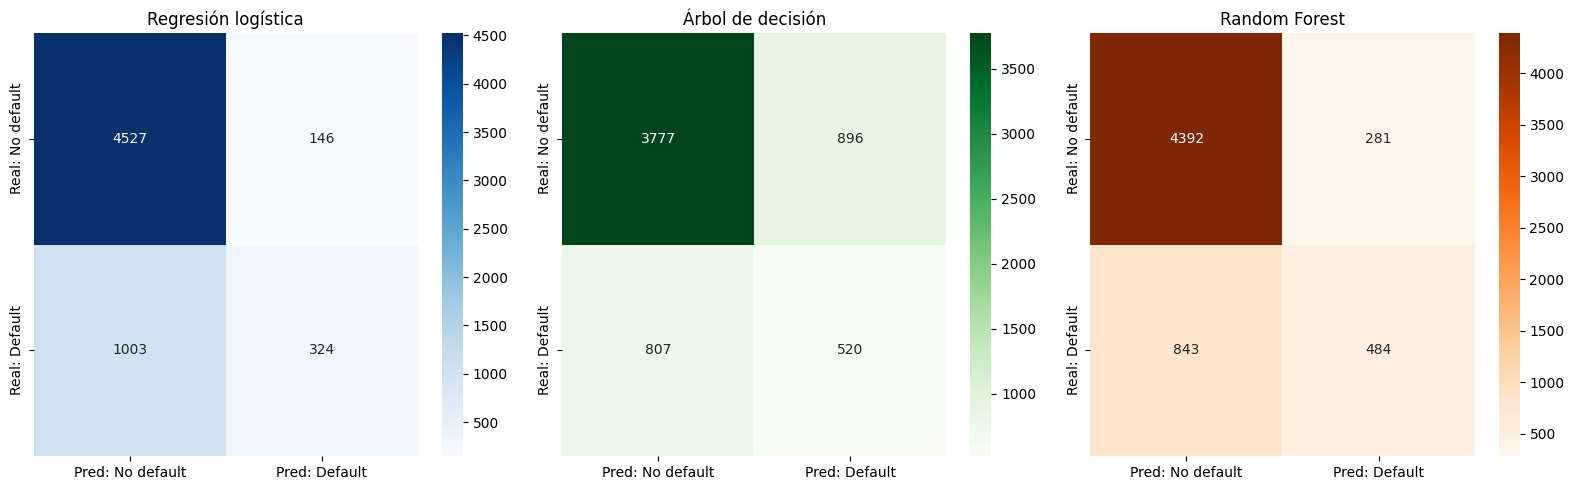

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.heatmap(cm_lr_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Regresión logística")

sns.heatmap(cm_tree_df, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Árbol de decisión")

sns.heatmap(cm_rf_df, annot=True, fmt="d", cmap="Oranges", ax=axes[2])
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()



La comparación visual entre las tres matrices de confusión permite distinguir mejor el comportamiento de cada modelo.

### Regresión logística
El mapa de calor muestra una concentración muy fuerte en la celda de **verdaderos negativos**, junto con muy pocos **falsos positivos**. Esto confirma que la regresión logística es el modelo más conservador: clasifica correctamente a muchos clientes sin incumplimiento, pero detecta relativamente pocos incumplimientos reales.

### Árbol de decisión
El árbol de decisión muestra una celda de **verdaderos positivos** más grande que la regresión logística, lo que indica una mejor detección de incumplimientos. Sin embargo, también presenta una celda muy grande de **falsos positivos**, lo cual refleja un exceso de falsas alarmas.

### Random Forest
Random Forest aparece visualmente como un punto intermedio más equilibrado:

- mantiene una celda grande de **verdaderos negativos**,
- logra una celda de **verdaderos positivos** mayor que la de la regresión logística,
- y evita el crecimiento excesivo de **falsos positivos** observado en el árbol de decisión.

### Comparación general
La representación gráfica refuerza la conclusión obtenida con las métricas:

- la **regresión logística** prioriza la estabilidad y la precisión,
- el **árbol de decisión** prioriza la detección de incumplimientos, pero con muchos errores,
- y **Random Forest** logra un compromiso más razonable entre ambos objetivos.

## Curvas ROC de los tres modelos

Para comparar la capacidad discriminante global de la regresión logística, el árbol de decisión y Random Forest, se construirán sus curvas ROC en una misma gráfica.

Esto permitirá observar cuál de los tres modelos separa mejor a los clientes con y sin incumplimiento a lo largo de distintos umbrales.

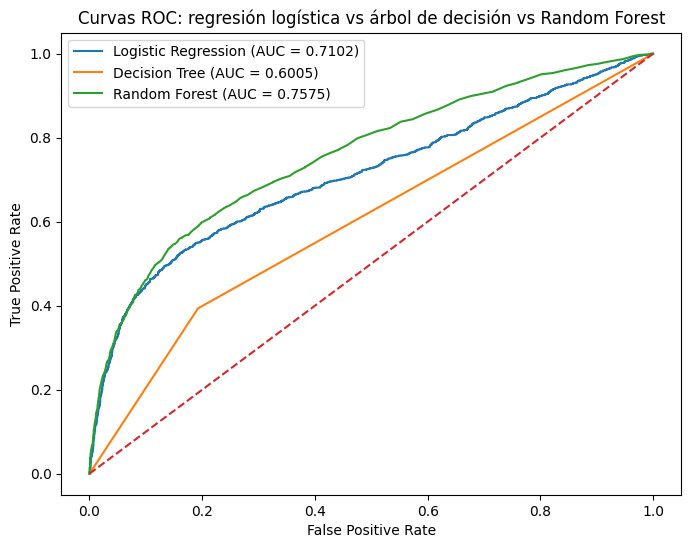

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_tree = roc_auc_score(y_test, y_proba_tree)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC: regresión logística vs árbol de decisión vs Random Forest")
plt.legend()
plt.show()



La comparación de las curvas ROC muestra con claridad una jerarquía entre los tres modelos:

- **Random Forest** obtiene el mejor desempeño global, con **AUC = 0.7575**.
- **Regresión logística** ocupa el segundo lugar, con **AUC = 0.7102**.
- **Árbol de decisión** presenta el peor desempeño, con **AUC = 0.6005**.

La curva de **Random Forest** se mantiene por encima de las otras dos en la mayor parte del rango, lo que indica que este modelo separa mejor a los clientes con y sin incumplimiento a lo largo de distintos umbrales.

La **regresión logística** sigue siendo competitiva y claramente superior al árbol de decisión, aunque su capacidad discriminante global es menor que la de Random Forest.

En cambio, el **árbol de decisión** se mantiene más cercano a la diagonal de referencia, lo que confirma que su capacidad para ordenar correctamente a los clientes según el riesgo es la más limitada de los tres modelos.

En conjunto, esta gráfica refuerza la conclusión obtenida con las métricas: **Random Forest** es, hasta este punto del proyecto, el modelo más sólido.

## Importancia de variables en Random Forest

Una ventaja importante de Random Forest es que permite calcular medidas de **importancia de variables**, las cuales indican qué predictores contribuyen más al desempeño del modelo.

En esta sección se identificarán las variables más relevantes según el Random Forest entrenado.

In [20]:
feature_names_num = numeric_features

ohe_rf = rf_clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe_rf.get_feature_names_out(categorical_features)

feature_names_rf = np.concatenate([feature_names_num, feature_names_cat])

importances_rf = rf_clf.named_steps["model"].feature_importances_

importance_rf_df = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False)

importance_rf_df.head(15)

,feature,importance
2,PAY_0,0.0976
0,LIMIT_BAL,0.0598
1,AGE,0.0593
8,BILL_AMT1,0.0580
9,BILL_AMT2,0.0523
14,PAY_AMT1,0.0499
10,BILL_AMT3,0.0495
11,BILL_AMT4,0.0495
12,BILL_AMT5,0.0493
13,BILL_AMT6,0.0492



Las variables más importantes en Random Forest muestran un patrón consistente con lo observado en sesiones anteriores, aunque con una distribución más equilibrada que la del árbol de decisión individual.

La variable más importante vuelve a ser:

- **`PAY_0`**, con una importancia de **0.0976**.

Esto confirma que el **estado de pago más reciente** sigue siendo la señal más fuerte para anticipar incumplimiento.

Después aparecen variables como:

- `LIMIT_BAL`,
- `AGE`,
- `BILL_AMT1`,
- `BILL_AMT2`,
- `PAY_AMT1`,
- y varios montos facturados y pagados.

### Interpretación general
A diferencia del árbol de decisión, donde `PAY_0` dominaba con mucha mayor diferencia, en Random Forest la importancia está más repartida entre varias variables. Esto sugiere que el modelo está aprovechando información de manera más robusta y menos dependiente de una sola partición dominante.

En conjunto, Random Forest parece basarse principalmente en:

1. el **historial reciente de mora**,
2. el **límite de crédito**,
3. la **edad**,
4. los **montos facturados**,
5. y los **montos pagados**.

Esto es razonable desde el punto de vista sustantivo: el riesgo de incumplimiento no depende únicamente de una variable aislada, sino de la interacción entre capacidad crediticia, comportamiento de pago y nivel reciente de deuda.

## Visualización de las variables más importantes en Random Forest

Para facilitar la interpretación, se representarán en una gráfica de barras las variables con mayor importancia en el modelo de Random Forest.

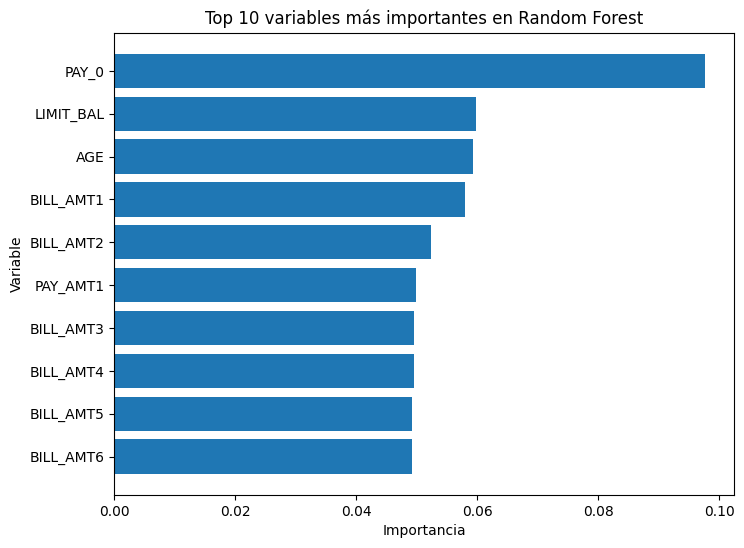

In [22]:
top_n = 10
top_features_rf = importance_rf_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_rf["feature"], top_features_rf["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes en Random Forest")
plt.show()


La gráfica confirma visualmente que **`PAY_0`** es la variable más influyente en Random Forest. Esto refuerza una conclusión que ha aparecido de manera consistente a lo largo del proyecto: el **estado de pago más reciente** es una señal central para anticipar incumplimiento.

Después de `PAY_0`, aparecen con importancia similar:

- `LIMIT_BAL`,
- `AGE`,
- `BILL_AMT1`,
- `BILL_AMT2`,
- `PAY_AMT1`,
- y varios montos facturados recientes.

La gráfica muestra además que, a diferencia del árbol de decisión individual, Random Forest distribuye la importancia de forma más balanceada entre varias variables. Esto es coherente con la lógica del modelo: al promediar muchos árboles, el ensamble reduce la dependencia excesiva de una sola regla o partición.

En términos sustantivos, el modelo está señalando que el riesgo de incumplimiento depende sobre todo de una combinación entre:

1. **historial reciente de mora**,
2. **límite de crédito**,
3. **edad**,
4. **nivel reciente de facturación**,
5. y **comportamiento de pago**.

Esto sugiere que Random Forest está capturando una estructura predictiva más rica y estable que la observada en el árbol individual.

## Conclusiones 

En esta sesión se compararon tres modelos para predecir incumplimiento de pago:

- **regresión logística**,
- **árbol de decisión**,
- **Random Forest**.

Los principales hallazgos fueron los siguientes:

1. La **regresión logística** mantuvo un comportamiento conservador, con buena precisión pero bajo recall.
2. El **árbol de decisión** detectó más incumplimientos, pero con un aumento importante en falsos positivos y menor desempeño global.
3. **Random Forest** obtuvo el mejor equilibrio entre los tres modelos:
   - mayor `accuracy`,
   - mayor `F1-score`,
   - y mayor `ROC-AUC`.

4. La comparación de matrices de confusión mostró que Random Forest detecta más incumplimientos que la regresión logística, pero sin generar tantas falsas alarmas como el árbol de decisión.
5. La comparación de curvas ROC confirmó que Random Forest posee la mejor capacidad discriminante global.
6. El análisis de importancia de variables indicó que `PAY_0` sigue siendo el predictor más relevante, acompañado por `LIMIT_BAL`, `AGE`, montos facturados y montos pagados.

En conjunto, los resultados sugieren que **Random Forest** es, hasta este punto del proyecto, el modelo más prometedor. Este modelo conserva la flexibilidad de los árboles, pero con mayor estabilidad y mejor desempeño predictivo que un árbol individual.



## Tarea 

Con base en los resultados obtenidos, realizar lo siguiente:

1. Elaborar una tabla comparativa con las métricas de los tres modelos:
   - accuracy,
   - precision,
   - recall,
   - F1-score,
   - ROC-AUC.

2. Redactar un párrafo donde expliques:
   - cuál modelo tuvo el mejor desempeño global,
   - cuál modelo detectó más incumplimientos,
   - y cuál modelo produjo más falsas alarmas.

3. Revisar las matrices de confusión y responder:
   - ¿qué modelo es más conservador?
   - ¿qué modelo es más agresivo?
   - ¿cuál parece lograr el mejor equilibrio?

4. Escribir una interpretación breve de las variables más importantes en Random Forest.

